In [29]:
library(car)
library(glmnet)
library(GGally)
library(ComplexHeatmap)
library(ggplotify)
library(caret)
library(pROC)

In [30]:
lipid_meta = read.csv('../data/var_importance.b1.csv')

In [31]:
scaled_df = read.csv('../data/merged_dataset.csv')
meta = read.csv('../data/merged_dataset_meta.csv')

became_data = scaled_df[rownames(subset(meta,cohort=='BECAME')),]
became_meta = meta[rownames(became_data),]
became_data$response_var = as.factor(as.numeric(became_meta[rownames(became_data),'cluster']=='B1'))


Total Observations: 175 
Events: 25 
Predictors: 161 
EPV: 0.1552795 


Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Minimum VIF: 131.9557 


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


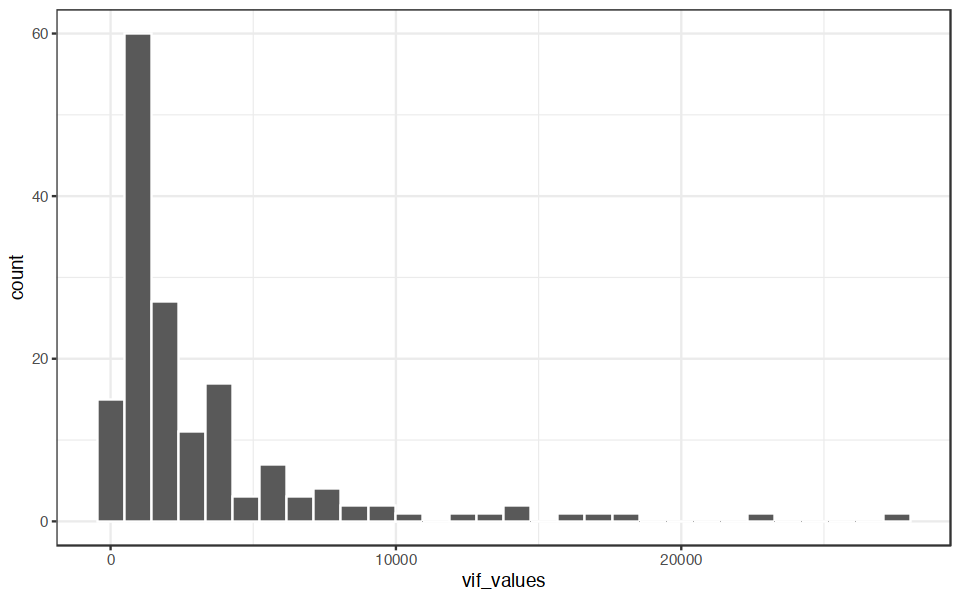

In [32]:
# Check the number of observations and events
total_obs <- nrow(became_data)
events <- sum(became_data$response_var == 1)

# Check EPV
predictor_count <- ncol(became_data) - 1  # Excluding the response variable
epv <- events / predictor_count

# Display results
cat("Total Observations:", total_obs, "\n")
cat("Events:", events, "\n")
cat("Predictors:", predictor_count, "\n")
cat("EPV:", epv, "\n")

# Check for multicollinearity using VIF
vif_values <- vif(glm(response_var ~ ., data = became_data, family = "binomial"))


# Display VIF values as histogram
options(repr.plot.width = 8, repr.plot.height = 5)

vif_values = data.frame(vif_values)
vif_values$lipid = rownames(vif_values)
cat("Minimum VIF:", min(vif_values$vif_values), "\n")
ggplot(vif_values,aes(vif_values))+
    geom_histogram(col='white')+
    theme_bw()

In [33]:
## Create Response Var

lipids = colnames(became_data)
became_data$response_var = as.factor(as.numeric(became_meta[rownames(became_data),'cluster']=='B1'))


Start:  AIC=107.22
response_var ~ 1



Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“the response appeared on the right-hand side and was dropped”
Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“problem with term 162 in model.matrix: no columns are assigned”


       Df Deviance     AIC
+ X3    1   54.217  63.842
+ X62   1   55.284  64.909
+ X64   1   64.318  73.942
+ X61   1   64.794  74.418
+ X83   1   69.028  78.652
+ X110  1   69.467  79.092
+ X78   1   70.093  79.717
+ X8    1   73.065  82.689
+ X144  1   74.377  84.002
+ X132  1   75.016  84.641
+ X51   1   75.664  85.288
+ X1    1   76.571  86.195
+ X133  1   77.385  87.010
+ X37   1   77.494  87.118
+ X63   1   77.659  87.284
+ X38   1   78.099  87.724
+ X58   1   78.132  87.756
+ X4    1   78.162  87.786
+ X56   1   78.197  87.821
+ X81   1   78.259  87.883
+ X134  1   78.305  87.929
+ X71   1   78.505  88.130
+ X124  1   79.205  88.829
+ X94   1   79.317  88.941
+ X128  1   79.450  89.074
+ X97   1   79.591  89.215
+ X16   1   80.110  89.734
+ X69   1   80.337  89.962
+ X77   1   80.408  90.032
+ X49   1   80.659  90.283
+ X80   1   80.867  90.491
+ X114  1   81.513  91.137
+ X54   1   81.572  91.196
+ X46   1   81.789  91.413
+ X119  1   81.920  91.544
+ X67   1   82.144  91.768
+

Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“the response appeared on the right-hand side and was dropped”
Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“problem with term 162 in model.matrix: no columns are assigned”


       Df Deviance     AIC
+ X64   1   35.747  50.184
+ X62   1   36.699  51.135
+ X63   1   38.032  52.469
+ X83   1   39.633  54.069
+ X94   1   40.034  54.470
+ X61   1   42.064  56.501
+ X97   1   42.723  57.160
+ X78   1   42.744  57.181
+ X80   1   43.205  57.641
+ X134  1   43.214  57.651
+ X148  1   43.535  57.972
+ X104  1   43.783  58.219
+ X105  1   44.157  58.594
+ X110  1   44.326  58.762
+ X38   1   45.150  59.587
+ X7    1   45.611  60.048
+ X16   1   45.739  60.176
+ X85   1   45.746  60.182
+ X11   1   45.776  60.212
+ X84   1   45.972  60.408
+ X112  1   46.190  60.626
+ X81   1   46.328  60.765
+ X102  1   46.365  60.802
+ X6    1   46.454  60.891
+ X77   1   46.622  61.058
+ X45   1   46.684  61.120
+ X144  1   46.819  61.256
+ X75   1   46.924  61.360
+ X71   1   46.961  61.398
+ X60   1   46.961  61.398
+ X99   1   47.008  61.444
+ X114  1   47.016  61.453
+ X67   1   47.065  61.502
+ X9    1   47.145  61.581
+ X69   1   47.150  61.586
+ X96   1   47.193  61.630
+

...


Step:  AIC=33.69
response_var ~ X3 + X64 + X105 + X119 + X95 + X7



Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“the response appeared on the right-hand side and was dropped”
Warning message in model.matrix.default(Terms, m, contrasts.arg = object$contrasts):
“problem with term 162 in model.matrix: no columns are assigned”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabil

       Df Deviance    AIC
<none>       0.000 33.685
+ X77   1    0.000 38.497
+ X110  1    0.000 38.497
+ X149  1    0.000 38.497
+ X83   1    0.000 38.497
+ X82   1    0.000 38.497
+ X30   1    0.000 38.497
+ X37   1    0.000 38.497
+ X62   1    0.000 38.497
+ X29   1    0.000 38.497
+ X134  1    0.000 38.497
+ X80   1    0.000 38.497
+ X2    1    0.000 38.497
+ X124  1    0.000 38.497
+ X161  1    0.000 38.497
+ X92   1    0.000 38.497
+ X150  1    0.000 38.497
+ X145  1    0.000 38.497
+ X86   1    0.000 38.497
+ X85   1    0.000 38.497
+ X125  1    0.000 38.497
+ X88   1    0.000 38.497
+ X138  1    0.000 38.497
+ X157  1    0.000 38.497
+ X43   1    0.000 38.497
+ X45   1    0.000 38.497
+ X75   1    0.000 38.497
+ X47   1    0.000 38.497
+ X151  1    0.000 38.497
+ X84   1    0.000 38.497
+ X33   1    0.000 38.497
+ X148  1    0.000 38.497
+ X39   1    0.000 38.497
+ X153  1    0.000 38.497
+ X112  1    0.000 38.497
+ X154  1    0.000 38.497
+ X76   1    0.000 38.497
+ X40   1   


Call:
glm(formula = response_var ~ X3 + X64 + X105 + X119 + X95 + X7, 
    family = "binomial", data = train_data)

Deviance Residuals: 
       Min          1Q      Median          3Q         Max  
-1.219e-04  -2.100e-08  -2.100e-08  -2.100e-08   1.486e-04  

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  -343.22   51046.68  -0.007    0.995
X3            111.33   17456.70   0.006    0.995
X64          -203.88   31034.48  -0.007    0.995
X105          -71.31   11752.16  -0.006    0.995
X119         -157.55   24360.89  -0.006    0.995
X95          -114.53   18064.46  -0.006    0.995
X7             61.15   10924.69   0.006    0.996

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1.0241e+02  on 122  degrees of freedom
Residual deviance: 9.5878e-08  on 116  degrees of freedom
AIC: 14

Number of Fisher Scoring iterations: 25


Setting levels: control = 0, case = 1

Setting direction: controls < cases



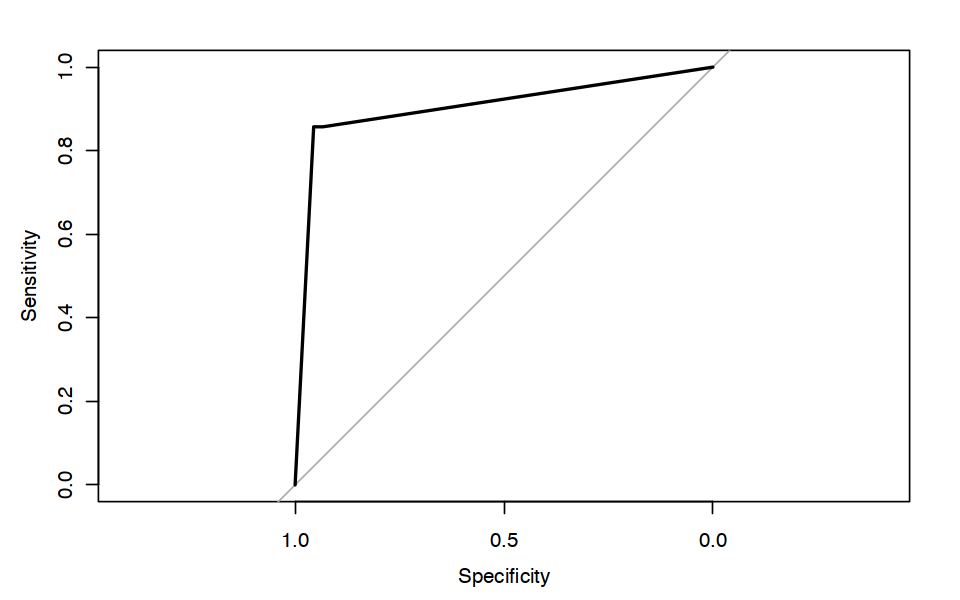

In [34]:

# Create a formula for the null model
null_model_formula <- as.formula(paste("response_var ~ 1"))
# Create a formula for lipids
lipids_formula <- as.formula(paste("response_var ~", paste(lipids, collapse = " + ")))


# Step 1: Split the data 
set.seed(123) # for reproducibility
index <- createDataPartition(became_data$response_var, p = 0.7, list = FALSE)
train_data <- became_data[index,]
test_data <- became_data[-index,]

# Step 2: Forward-backward feature selection with BIC on lipids
null_model <- glm(null_model_formula, data = train_data, family = 'binomial')
lipids_model <- step(null_model, direction = "both", 
                     scope = list(lower = null_model_formula, upper = lipids_formula), 
                     k = log(nrow(train_data))) # trace=FALSE suppresses output

# Print out the selected lipid model
summary(lipids_model)


# Step 4: Evaluation of the final model with ROC and AUC
probabilities <- predict(lipids_model, newdata = test_data, type = "response")
roc_obj <- roc(test_data$response_var, probabilities)

# ROC curve
plot(roc_obj)

# AUC with 95% bootstrap confidence intervals
auc_value <- auc(roc_obj)
ci <- ci.auc(roc_obj, boot.n = 1000) # number of bootstraps



In [35]:
lipids_model


Call:  glm(formula = response_var ~ X3 + X64 + X105 + X119 + X95 + X7, 
    family = "binomial", data = train_data)

Coefficients:
(Intercept)           X3          X64         X105         X119          X95  
    -343.22       111.33      -203.88       -71.31      -157.55      -114.53  
         X7  
      61.15  

Degrees of Freedom: 122 Total (i.e. Null);  116 Residual
Null Deviance:	    102.4 
Residual Deviance: 9.588e-08 	AIC: 14

In [36]:
table(data.frame(cbind(test_data$response_var,round(probabilities)+1)))

   X2
X1   1  2
  1 43  2
  2  1  6